## 7. Perfil lipídico

### Objetivo

Esta seção tem como objetivo caracterizar o **colesterol total** dos participantes e investigar sua relação com o histórico informado de colesterol elevado.

Inicialmente, são analisadas a distribuição da medida laboratorial, suas principais estatísticas descritivas e a presença de valores extremos. Em seguida, o colesterol total medido é comparado com a informação autorreferida pelos participantes, além de ser investigada sua associação linear com a idade.

A análise possui caráter descritivo. O histórico informado e a medida laboratorial atual representam informações relacionadas, mas distintas, e não serão utilizados isoladamente para estabelecer diagnóstico clínico.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Identidade visual do HealthSync
COR_PRINCIPAL = "#0E766D"
COR_SECUNDARIA = "#10B981"
COR_TERCIARIA = "#14B8A6"

COR_DESTAQUE = "#F28C82"
COR_NEUTRA = "#94A3B8"

# Cores consistentes para respostas binárias
COR_SIM = COR_PRINCIPAL
COR_NAO = COR_NEUTRA

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

plt.rcParams["figure.dpi"] = 120

Abrindo o csv, e testando se carregou corretamente


In [5]:
CAMINHO_CORE = "../../dataset/healthsync_nhanes_2021_2023_core.csv"

df = pd.read_csv(CAMINHO_CORE)

display(df.head())

,id_participante,peso_estatistico_mec,peso_estatistico_entrevista,psu,estrato_amostral,idade,sexo,imc,pressao_sistolica,pressao_diastolica,...,glicose_jejum,colesterol_total,diabetes_informado,hipertensao_informada,hipertensao_2consultas,colesterol_alto_informado,medicamento_pressao,atv_moderada_min_semana,atv_vigorosa_min_semana,minutos_sedentarios_dia
0,130378.0,54.374.463.898,50.055.450.807,2.0,173.0,43.0,Homem,27.0,132.7,96.0,...,113.0,264.0,Nao,1.0,1.0,0.0,1.0,135.0,135.0,360.0
1,130379.0,34.084.721.548,29.087.450.605,2.0,173.0,66.0,Homem,33.5,117.0,78.7,...,99.0,214.0,Nao,1.0,1.0,0.0,1.0,180.0,135.0,480.0
2,130380.0,81.196.277.992,80.062.674.301,1.0,174.0,44.0,Mulher,29.7,109.0,78.3,...,156.0,187.0,Sim,0.0,NaN,1.0,NaN,20.0,0.0,240.0
3,130386.0,3.998.845.294,3.099.528.261,1.0,179.0,34.0,Homem,30.2,115.0,73.7,...,100.0,183.0,Nao,0.0,NaN,0.0,NaN,30.0,6.9,180.0
4,130387.0,2.077.625.485,19.896.970.559,1.0,181.0,68.0,Mulher,42.6,141.3,76.0,...,NaN,203.0,Nao,1.0,1.0,1.0,1.0,0.0,0.0,1200.0


### 7.1 Resumo do colesterol total

**Pergunta da análise:** quais são as principais características dos valores de colesterol total na amostra?

Antes da análise gráfica, são utilizadas estatísticas descritivas para avaliar a tendência central, a dispersão, a amplitude e a disponibilidade dessa medida laboratorial.

In [6]:
resumo_colesterol = (
    df["colesterol_total"]
    .describe()
    .round(2)
)

display(resumo_colesterol)

print(
    f"Valores ausentes: {df['colesterol_total'].isna().sum()} "
    f"({df['colesterol_total'].isna().mean() * 100:.2f}%)"
)

count    5283.00
mean      188.52
std        42.55
min        62.00
25%       159.00
50%       186.00
75%       214.00
max       438.00
Name: colesterol_total, dtype: float64

Valores ausentes: 0 (0.00%)


O colesterol total apresentou média de **188,52 mg/dL** e mediana de **186 mg/dL**, com metade dos participantes apresentando valores entre **159 e 214 mg/dL**.

Os valores observados variaram entre **62 e 438 mg/dL**, indicando uma amplitude considerável na amostra.

A variável está disponível para todos os **5.283 participantes**, não apresentando valores ausentes na base CORE. Isso permite analisar o colesterol total sem necessidade de redução da amostra devido à ausência dessa medida.

### 7.2 Distribuição do colesterol total

**Pergunta da análise:** como os valores de colesterol total estão distribuídos entre os participantes?

O histograma permite observar o formato geral da distribuição e identificar as regiões de maior concentração dos valores. Essa visualização complementa as estatísticas descritivas apresentadas anteriormente e permite verificar possíveis assimetrias e observações afastadas da região central.

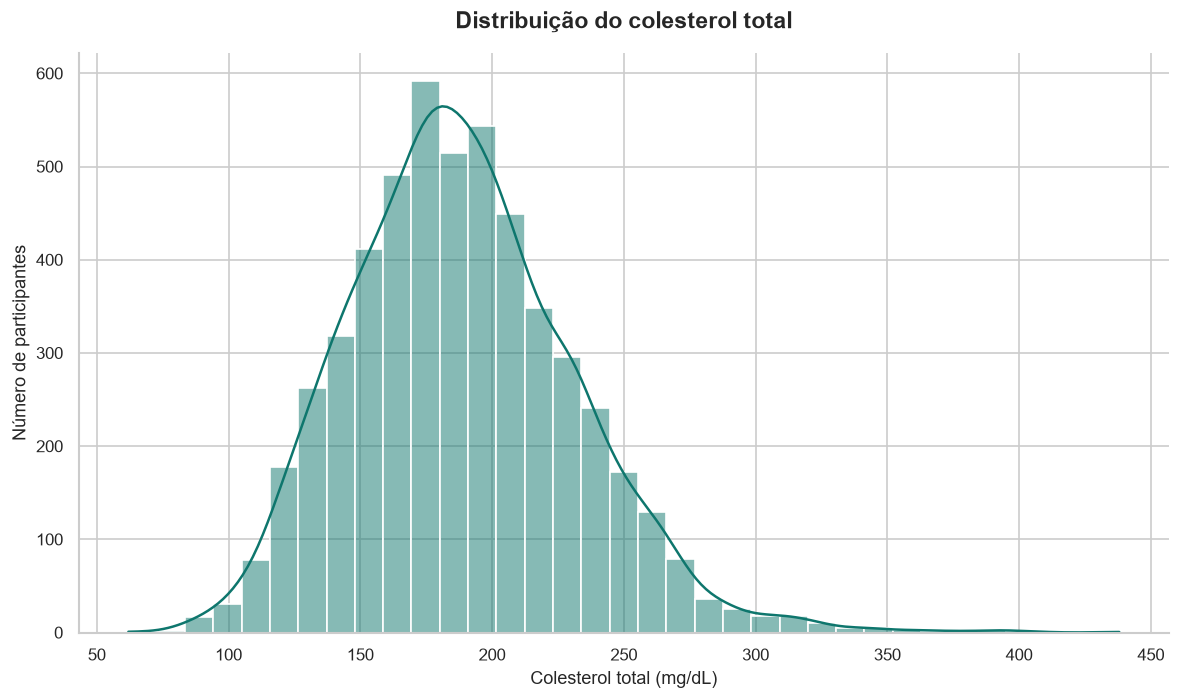

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="colesterol_total",
    bins=35,
    kde=True,
    color=COR_PRINCIPAL,
    edgecolor="white"
)

plt.title(
    "Distribuição do colesterol total",
    pad=15,
    weight="bold"
)

plt.xlabel("Colesterol total (mg/dL)")
plt.ylabel("Número de participantes")

sns.despine()

plt.tight_layout()
plt.show()

A distribuição do colesterol total apresenta maior concentração dos participantes em torno dos valores centrais observados na amostra, acompanhada de menor frequência à medida que os valores se afastam dessa região.

São observados participantes com valores mais elevados e mais reduzidos de colesterol total. Entretanto, a visualização da distribuição, isoladamente, não permite classificar essas observações como erros.

Por esse motivo, as extremidades da distribuição são inspecionadas separadamente na próxima etapa.

### 7.3 Inspeção dos valores extremos

**Objetivo:** examinar as observações localizadas nas extremidades da distribuição do colesterol total.

São inspecionados os participantes com maiores e menores valores, considerando também idade, sexo, IMC e histórico informado de colesterol elevado. Em seguida, o boxplot é utilizado para visualizar a posição dessas observações em relação à região central da distribuição.

A inspeção possui caráter exploratório. Valores visualmente extremos não serão considerados automaticamente erros de registro.

In [8]:
maiores_colesterol = (
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "imc",
            "colesterol_total",
            "colesterol_alto_informado"
        ]
    ]
    .sort_values(
        "colesterol_total",
        ascending=False
    )
    .head(20)
)

display(maiores_colesterol)

,id_participante,idade,sexo,imc,colesterol_total,colesterol_alto_informado
2714,136573.0,57.0,Mulher,23.0,438.0,0.0
3768,138873.0,40.0,Mulher,28.0,405.0,0.0
3719,138765.0,55.0,Mulher,25.2,398.0,1.0
2724,136591.0,57.0,Homem,24.2,393.0,0.0
1200,133076.0,59.0,Homem,32.8,391.0,1.0
2439,135957.0,53.0,Mulher,37.2,389.0,1.0
5251,142241.0,51.0,Homem,34.0,376.0,1.0
2600,136318.0,58.0,Mulher,28.2,376.0,1.0
2312,135661.0,59.0,Homem,27.5,364.0,1.0
2480,136050.0,25.0,Mulher,25.1,362.0,1.0


In [9]:
menores_colesterol = (
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "imc",
            "colesterol_total",
            "colesterol_alto_informado"
        ]
    ]
    .sort_values(
        "colesterol_total"
    )
    .head(20)
)

display(menores_colesterol)

,id_participante,idade,sexo,imc,colesterol_total,colesterol_alto_informado
2732,136607.0,59.0,Homem,27.6,62.0,1.0
2116,135217.0,49.0,Homem,24.0,74.0,1.0
5199,142103.0,66.0,Mulher,27.1,80.0,1.0
4590,140714.0,63.0,Homem,25.6,84.0,0.0
1407,133536.0,68.0,Homem,41.2,84.0,1.0
41,130465.0,77.0,Homem,37.9,84.0,0.0
4430,140404.0,70.0,Mulher,20.1,86.0,0.0
4621,140777.0,53.0,Mulher,33.3,86.0,1.0
1716,134280.0,25.0,Mulher,19.9,87.0,0.0
2709,136564.0,58.0,Mulher,30.0,87.0,0.0


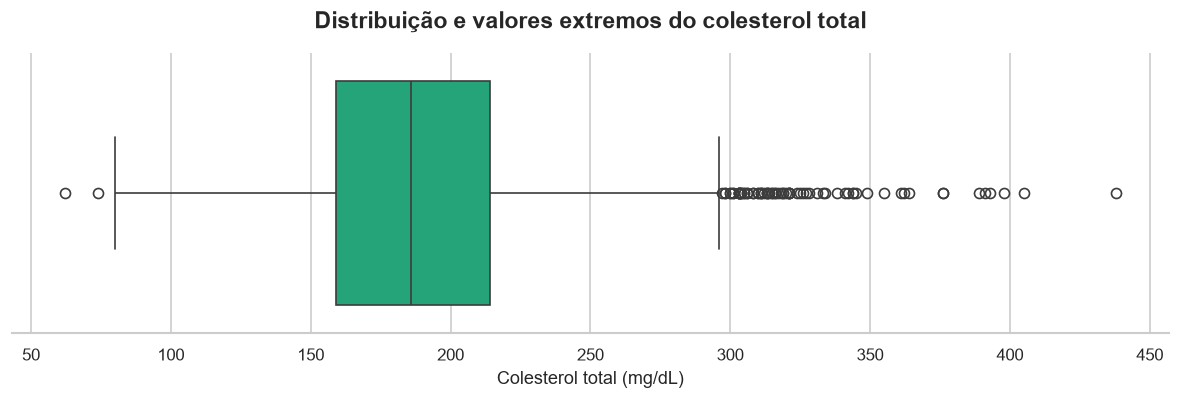

In [10]:
plt.figure(figsize=(10, 3.5))

sns.boxplot(
    data=df,
    x="colesterol_total",
    color=COR_SECUNDARIA
)

plt.title(
    "Distribuição e valores extremos do colesterol total",
    pad=15,
    weight="bold"
)

plt.xlabel("Colesterol total (mg/dL)")
plt.ylabel("")

sns.despine(left=True)

plt.tight_layout()
plt.show()

A inspeção confirma a presença de observações afastadas da região central da distribuição, com valores de colesterol total variando entre **62 e 438 mg/dL**.

O boxplot evidencia principalmente observações na extremidade superior da distribuição. Entretanto, a posição de um participante além dos limites visuais do boxplot não significa, por si só, que o valor seja incorreto.

Também são observadas diferentes respostas sobre histórico de colesterol elevado entre os participantes localizados nas extremidades da distribuição. Essas diferenças não serão interpretadas como confirmação ou ausência de uma condição clínica.

Como não foram identificadas evidências suficientes para classificar essas observações como erros de registro, os valores foram preservados na análise.

### 7.4 Colesterol alto informado

**Pergunta da análise:** qual é a distribuição do histórico informado de colesterol elevado entre os participantes?

Além da medida laboratorial atual, o NHANES contém uma variável referente ao histórico informado de colesterol alto.

Para facilitar a apresentação dos resultados, a codificação numérica da variável é convertida em rótulos "Não" e "Sim". Essa transformação é utilizada apenas para visualização e não altera os dados originais.

In [11]:
df["colesterol_alto_label"] = (
    df["colesterol_alto_informado"]
    .map({
        0.0: "Não",
        1.0: "Sim"
    })
)

distribuicao_colesterol_informado = (
    df["colesterol_alto_label"]
    .value_counts(dropna=False)
    .rename_axis("Colesterol alto informado")
    .reset_index(name="Quantidade")
)

display(distribuicao_colesterol_informado)

,Colesterol alto informado,Quantidade
0,Não,3048
1,Sim,2204
2,NaN,31


In [12]:
percentual_colesterol_informado = (
    df["colesterol_alto_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

display(percentual_colesterol_informado)

colesterol_alto_label
Não    58.0
Sim    42.0
Name: proportion, dtype: float64

Entre os participantes com informação disponível, **3.048 (58,0%)** não informaram histórico de colesterol alto, enquanto **2.204 (42,0%)** informaram a condição.

Apenas **31 participantes** não possuem resposta disponível nessa variável.

Essas proporções descrevem o histórico informado pelos participantes e não devem ser interpretadas como prevalência determinada exclusivamente por exames laboratoriais.

### 7.5 Colesterol medido × colesterol alto informado

**Pergunta da análise:** a distribuição do colesterol total medido difere entre participantes que informaram ou não histórico de colesterol elevado?

Esta análise compara a medida laboratorial atual com o histórico informado pelos participantes.

Primeiramente, são calculadas estatísticas descritivas para os dois grupos. Em seguida, o gráfico de violino permite comparar a distribuição completa dos valores, incluindo tendência central, dispersão e sobreposição entre os grupos.

O objetivo é investigar uma associação descritiva entre as duas informações, e não utilizar o exame atual para confirmar ou descartar individualmente o histórico informado.

In [13]:
resumo_colesterol_informado = (
    df
    .groupby(
        "colesterol_alto_label",
        observed=True
    )
    .agg(
        participantes=(
            "id_participante",
            "count"
        ),
        media=(
            "colesterol_total",
            "mean"
        ),
        mediana=(
            "colesterol_total",
            "median"
        ),
        desvio_padrao=(
            "colesterol_total",
            "std"
        ),
        minimo=(
            "colesterol_total",
            "min"
        ),
        maximo=(
            "colesterol_total",
            "max"
        )
    )
    .round(2)
)

display(resumo_colesterol_informado)

,participantes,media,mediana,desvio_padrao,minimo,maximo
colesterol_alto_label,,,,,,
Não,3048,186.42,185.0,38.73,84.0,438.0
Sim,2204,191.40,187.0,47.13,62.0,398.0


Os participantes que não informaram colesterol alto apresentaram média de **186,42 mg/dL** e mediana de **185 mg/dL**. Entre aqueles que informaram a condição, a média foi de **191,40 mg/dL** e a mediana de **187 mg/dL**.

Embora o grupo que informou colesterol alto apresente valores médios ligeiramente superiores, a diferença entre as medidas centrais dos dois grupos é relativamente pequena.

A comparação das distribuições permite avaliar se essa proximidade também ocorre ao longo dos demais valores observados.

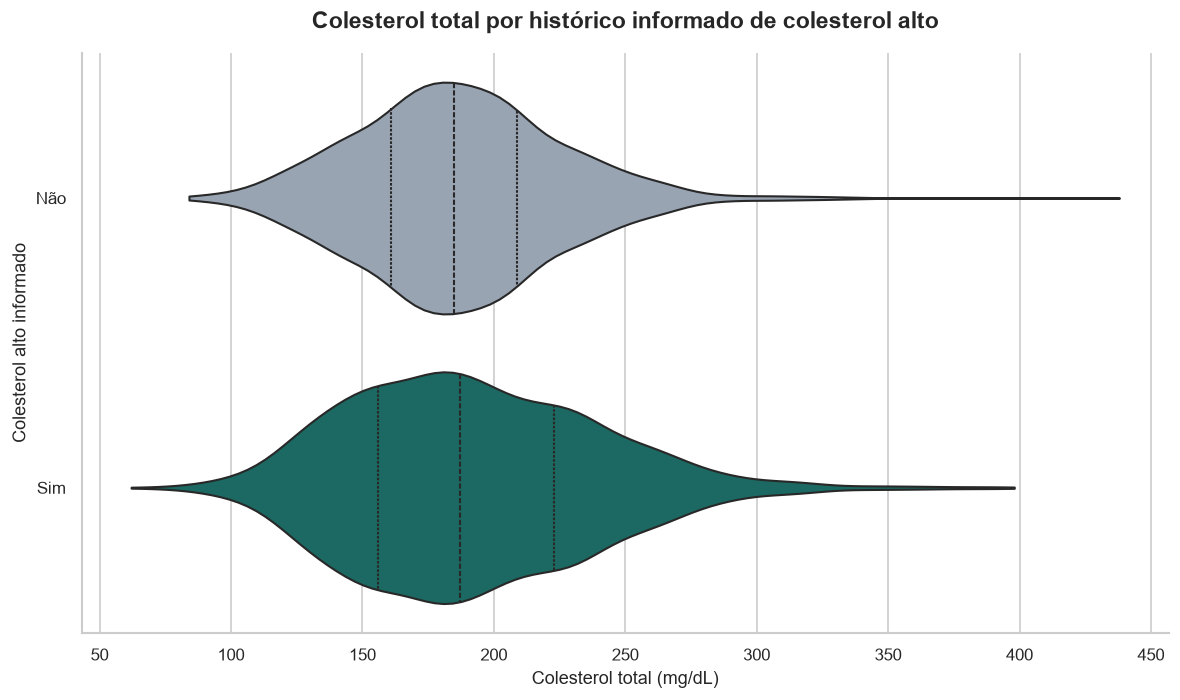

In [14]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    y="colesterol_alto_label",
    x="colesterol_total",
    order=["Não", "Sim"],
    hue="colesterol_alto_label",
    palette={
        "Não": COR_NEUTRA,
        "Sim": COR_PRINCIPAL
    },
    inner="quartile",
    cut=0,
    legend=False
)

plt.title(
    "Colesterol total por histórico informado de colesterol alto",
    pad=15,
    weight="bold"
)

plt.xlabel("Colesterol total (mg/dL)")
plt.ylabel("Colesterol alto informado")

sns.despine()

plt.tight_layout()
plt.show()

O gráfico evidencia considerável sobreposição das distribuições de colesterol total entre participantes que informaram e não informaram histórico de colesterol elevado.

Embora existam diferenças nas medidas centrais dos grupos, o colesterol total observado no momento do exame não separa claramente as duas categorias de histórico informado.

Esse resultado reforça que a medida laboratorial atual e o histórico relatado representam informações distintas. Entre outros fatores, tratamentos ou mudanças ocorridas ao longo do tempo podem contribuir para diferenças entre essas informações, mas os dados analisados não permitem determinar individualmente as razões dessas diferenças.

### 7.6 Colesterol total × idade

**Pergunta da análise:** existe associação linear entre idade e colesterol total na amostra?

A idade é uma característica demográfica potencialmente relevante para o perfil cardiometabólico. Por esse motivo, é calculado o coeficiente de correlação de Pearson entre idade e colesterol total.

O coeficiente permite avaliar a direção e a intensidade da associação linear entre as duas variáveis.

In [15]:
corr_idade_colesterol = (
    df[
        [
            "idade",
            "colesterol_total"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlação idade × colesterol total: "
    f"{corr_idade_colesterol:.3f}"
)

Correlação idade × colesterol total: -0.005


A correlação de Pearson entre idade e colesterol total foi de **-0,005**, valor muito próximo de zero.

Na amostra analisada, portanto, não foi observada uma associação linear relevante entre essas duas variáveis.

Esse resultado não significa que idade e colesterol sejam necessariamente independentes em todos os contextos. O coeficiente de Pearson avalia especificamente associação linear e pode não representar relações mais complexas ou influenciadas por outras características dos participantes.

### 7.7 Síntese do perfil lipídico

O colesterol total apresentou ampla variação entre os participantes, com média de **188,52 mg/dL** e mediana de **186 mg/dL**, além de disponibilidade completa na base CORE.

Foram identificadas observações afastadas da região central da distribuição, mas não foram encontradas evidências suficientes para classificá-las automaticamente como erros, sendo esses registros preservados.

A comparação segundo o histórico informado de colesterol alto mostrou valores médios ligeiramente superiores entre os participantes que informaram a condição. Entretanto, as distribuições apresentaram considerável sobreposição, indicando que a medida laboratorial atual e o histórico informado não são informações equivalentes.

Por fim, não foi observada associação linear relevante entre idade e colesterol total na amostra analisada.

Esses resultados contribuem para a caracterização do perfil cardiometabólico dos participantes e serão considerados posteriormente na seleção das variáveis utilizadas na etapa de Machine Learning.

O colesterol total compõe o conjunto de indicadores utilizados para caracterizar o perfil cardiometabólico dos participantes e poderá contribuir como informação complementar nas análises realizadas pelo HealthSync.